In [1]:
# Cell 1 - Setup + chargement + nettoyage (autonome)
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')

DATA_PATH = './data/data brut/'

print('=== Investigation Notebook (Autonome) ===')
print('Chargement des données source...')

df_main = pd.read_csv(os.path.join(DATA_PATH, 'olympics_dataset.csv'), sep=';', low_memory=False)
df_age = pd.read_csv(os.path.join(DATA_PATH, 'olympics_age.csv'), low_memory=False)

if 'name' in df_age.columns:
    df_age = df_age.rename(columns={'name': 'Name'})
if 'age' in df_age.columns:
    df_age = df_age.rename(columns={'age': 'Age'})

print(f'Dataset principal: {df_main.shape}')
print(f'Dataset age: {df_age.shape}')

# Nettoyage identique au pipeline principal
if 'Season' in df_main.columns:
    df_main = df_main.drop(columns=['Season'])

def normalize_name(s):
    return (
        s.astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r'[^a-z0-9]', '', regex=True)
    )

df = df_main.copy()
age_aux = df_age.copy()
age_aux['Age'] = pd.to_numeric(age_aux['Age'], errors='coerce')
age_aux['year'] = pd.to_numeric(age_aux.get('year'), errors='coerce')
age_aux['noc'] = age_aux.get('noc', pd.Series(index=age_aux.index, dtype='object')).astype(str).str.upper().str.strip()
age_aux['sex'] = age_aux.get('sex', pd.Series(index=age_aux.index, dtype='object')).astype(str).str.strip()

age_group = (
    age_aux.dropna(subset=['Age', 'year'])
    .groupby(['noc', 'year', 'sex'], as_index=False)['Age']
    .median()
    .rename(columns={'noc': 'NOCKey', 'year': 'YearKey', 'sex': 'SexKey', 'Age': 'Age_group'})
)

df['NOCKey'] = df['NOC'].astype(str).str.upper().str.strip()
df['YearKey'] = pd.to_numeric(df['Year'], errors='coerce')
df['SexKey'] = df['Sex'].map({'M': 'Male', 'F': 'Female'}).fillna(df['Sex'])

df = df.merge(age_group, on=['NOCKey', 'YearKey', 'SexKey'], how='left')
df['Age'] = df['Age_group']

name_aux = df_age[['Name', 'Age']].copy()
name_aux['Age'] = pd.to_numeric(name_aux['Age'], errors='coerce')
name_aux = name_aux.dropna(subset=['Name', 'Age'])
name_aux['name_key'] = normalize_name(name_aux['Name'])
age_by_name = name_aux.groupby('name_key')['Age'].median()

df['name_key'] = normalize_name(df['Name'])
df['name_key_drop1'] = normalize_name(df['Name'].str[1:])

missing_age_mask = df['Age'].isna()
df.loc[missing_age_mask, 'Age'] = df.loc[missing_age_mask, 'name_key'].map(age_by_name)
missing_age_mask = df['Age'].isna()
df.loc[missing_age_mask, 'Age'] = df.loc[missing_age_mask, 'name_key_drop1'].map(age_by_name)

sport_age_median = df.groupby('Sport')['Age'].transform('median')
df['Age'] = df['Age'].fillna(sport_age_median)
df['Age'] = df['Age'].fillna(df['Age'].median())

df = df[(df['Age'] >= 14) & (df['Age'] <= 45)].copy()
df = df[df['Year'] >= 1960].copy()

df['Medal'] = df['Medal'].fillna('No medal').astype(str).str.strip()
df['has_medal'] = (df['Medal'].str.lower() != 'no medal').astype(int)

df = df.drop(columns=['NOCKey', 'YearKey', 'SexKey', 'Age_group', 'name_key', 'name_key_drop1'], errors='ignore')

print(f'Nettoyage OK: {df.shape[0]:,} lignes | Taux médaille: {df["has_medal"].mean():.2%}')

=== Investigation Notebook (Autonome) ===
Chargement des données source...
Dataset principal: (252565, 11)
Dataset age: (300714, 8)
Nettoyage OK: 196,266 lignes | Taux médaille: 14.41%


In [2]:
# Cell 2 - Feature engineering + modèle (autonome)
print('\nCréation des features historiques...')

df = df.sort_values(['Year', 'Name', 'player_id']).reset_index(drop=True)
global_medal_rate = df['has_medal'].mean()

# Athlète
df['particip_athlete'] = df.groupby('Name').cumcount()
df['nb_medal_athlete'] = df.groupby('Name')['has_medal'].transform(lambda s: s.cumsum().shift(fill_value=0))
df['medal_ratio_athlete'] = np.where(
    df['particip_athlete'] > 0,
    df['nb_medal_athlete'] / df['particip_athlete'],
    0.0
)

# Pays
df['nb_athlete_country'] = df.groupby('NOC').cumcount()
df['nb_medal_country'] = df.groupby('NOC')['has_medal'].transform(lambda s: s.cumsum().shift(fill_value=0))
is_new_sport_country = (~df.duplicated(subset=['NOC', 'Sport'])).astype(int)
df['nb_sport_country'] = is_new_sport_country.groupby(df['NOC']).cumsum().shift(fill_value=0)

# Sport
df['sport_events_before'] = df.groupby('Sport').cumcount()
df['sport_medals_before'] = df.groupby('Sport')['has_medal'].transform(lambda s: s.cumsum().shift(fill_value=0))
df['medal_rate_sport'] = np.where(
    df['sport_events_before'] > 0,
    df['sport_medals_before'] / df['sport_events_before'],
    global_medal_rate
)

# Temporel
df['year_from_first'] = df['Year'] - df.groupby('Name')['Year'].transform('min')

df = df.drop(columns=['sport_events_before', 'sport_medals_before'], errors='ignore')

feature_cols = [
    'nb_medal_athlete', 'medal_ratio_athlete', 'particip_athlete',
    'nb_medal_country', 'nb_athlete_country', 'nb_sport_country',
    'medal_rate_sport', 'year_from_first', 'Age', 'Year'
]

X = df[feature_cols].copy().fillna(df[feature_cols].mean())
y = df['has_medal'].copy()

# Split temporel + scaling + training
train_mask = df['Year'] <= 2016
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_weight_ratio,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)

y_proba_test = model.predict_proba(X_test_scaled)[:, 1]
test_auc = roc_auc_score(y_test, y_proba_test)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f'Features prêtes: {len(feature_cols)}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Test AUC: {test_auc:.4f}')


Création des features historiques...
Features prêtes: 10
Train: 166,254 | Test: 30,012
Test AUC: 0.7461



INVESTIGATION MULTI-FEATURES - VERSION AUTONOME

Tableau synthétique (trié par importance modèle):
            feature  corr_with_target  model_importance  mean_medal  mean_non_medal  delta_mean  effect_size_std  q5_minus_q1_medal_rate
medal_ratio_athlete            0.2679            0.3087      0.2131          0.0442      0.1690           0.5836                  0.1574
   nb_medal_country            0.1923            0.1682    593.2659        297.2925    295.9734           0.4750                  0.2247
   nb_medal_athlete            0.2026            0.1592      0.5200          0.1255      0.3946           0.4249                  0.1574
   medal_rate_sport            0.1975            0.0893      0.1736          0.1332      0.0404           0.5412                  0.1928
 nb_athlete_country            0.1490            0.0633   2706.3647       1840.4013    865.9635           0.4004                  0.1471
               Year            0.0237            0.0574   1997.1501       1995

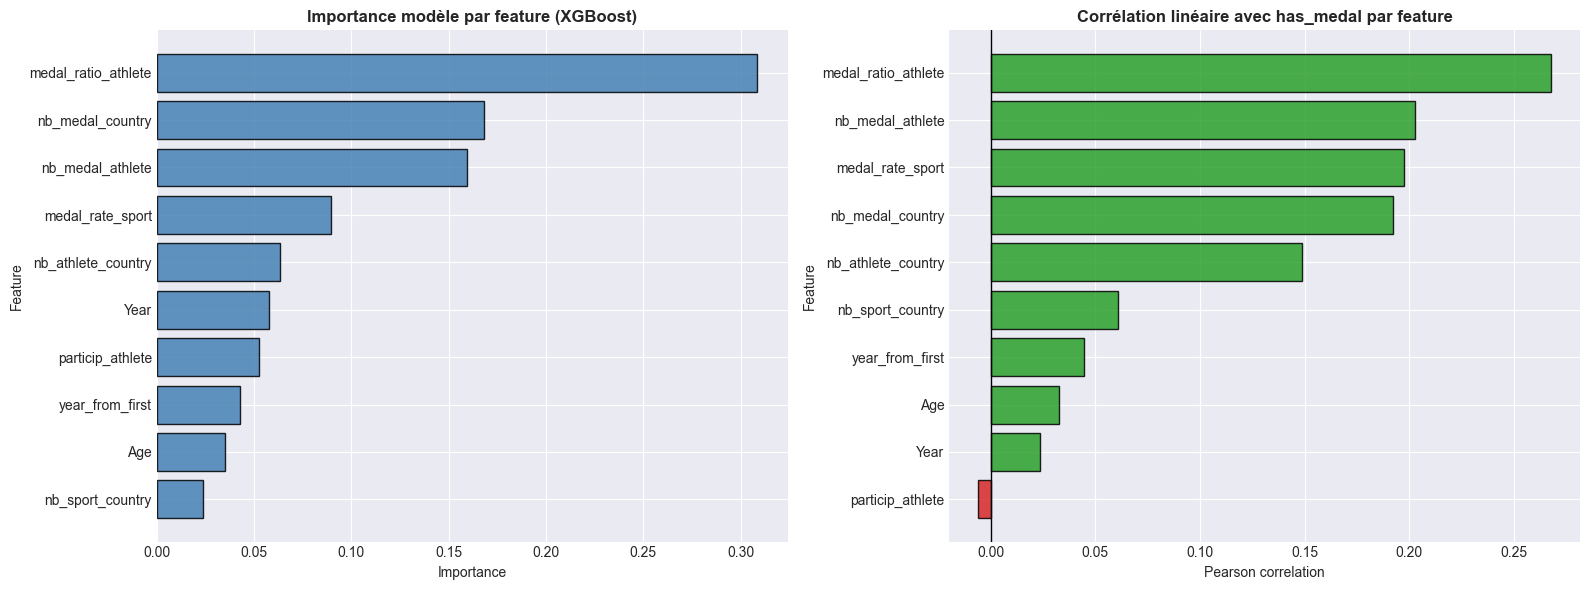

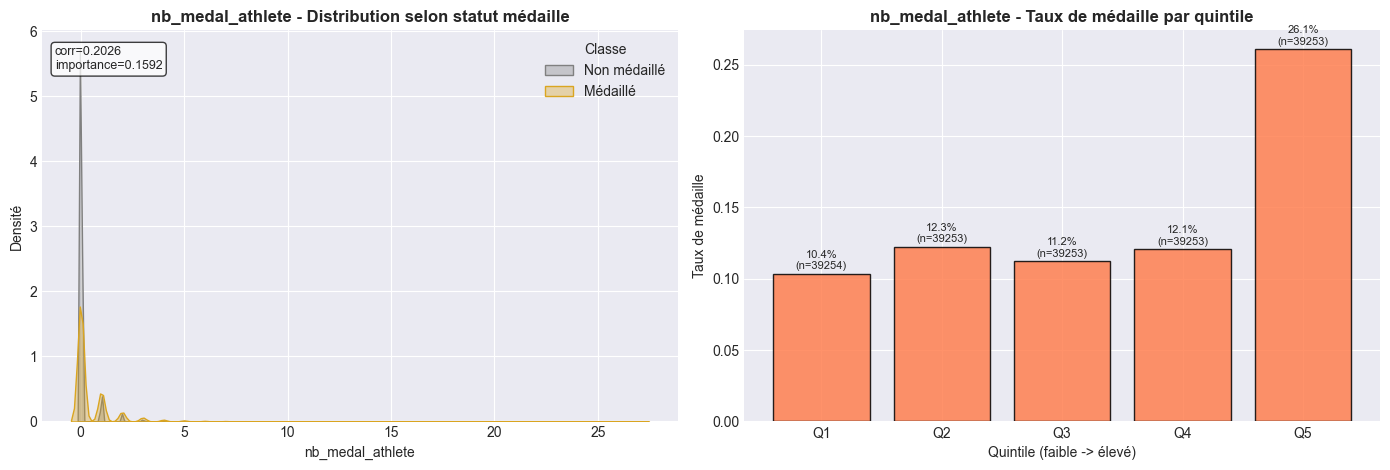

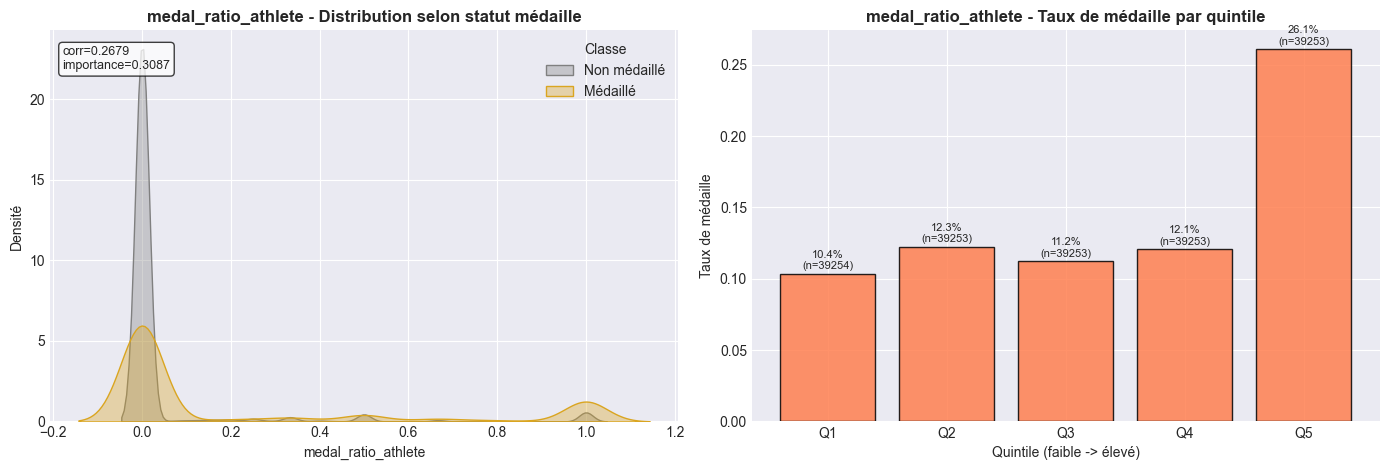

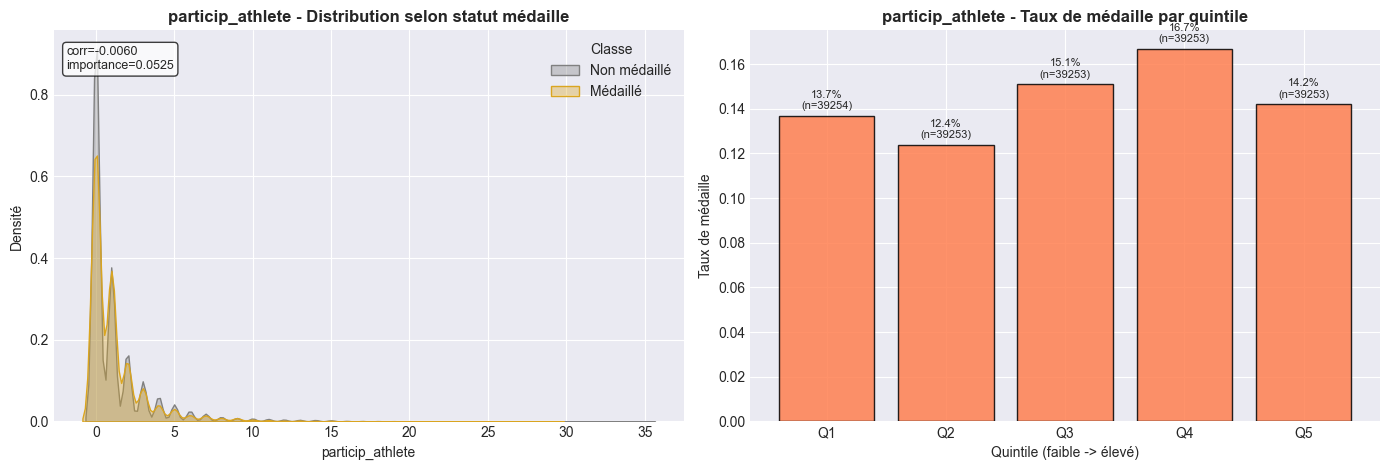

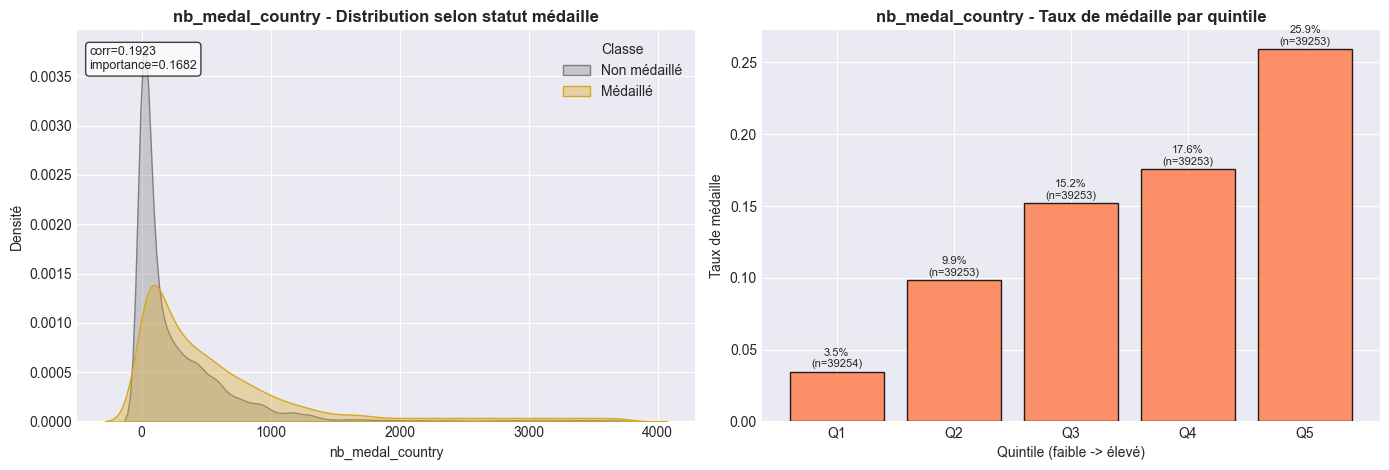

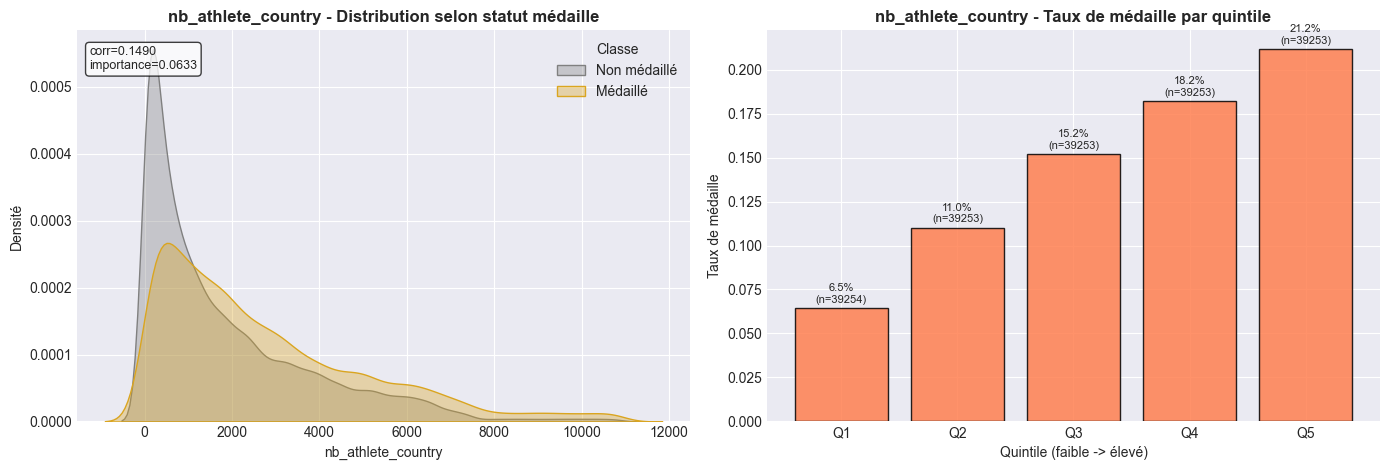

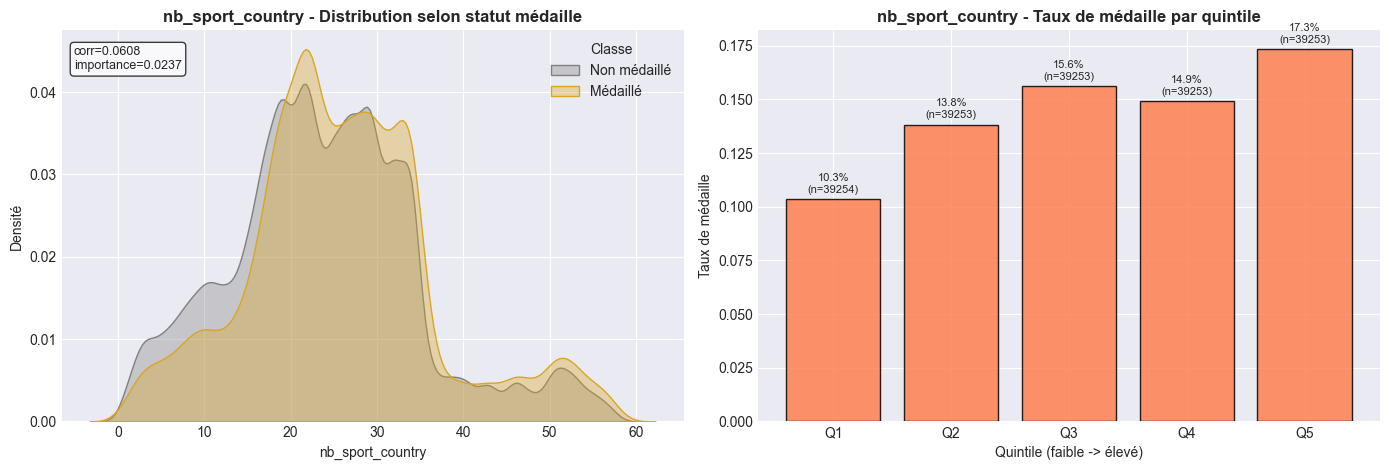

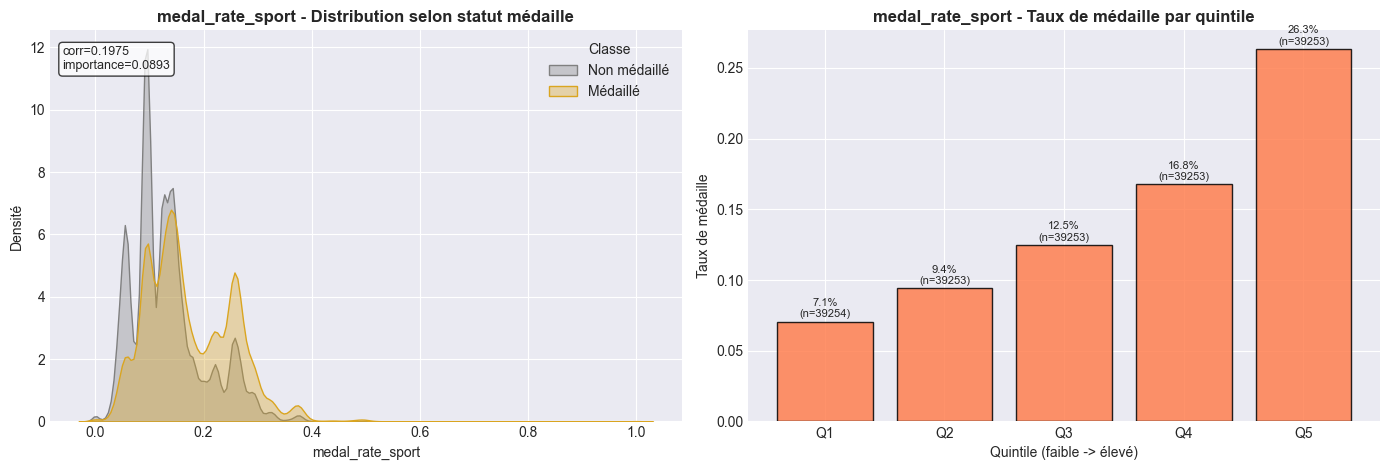

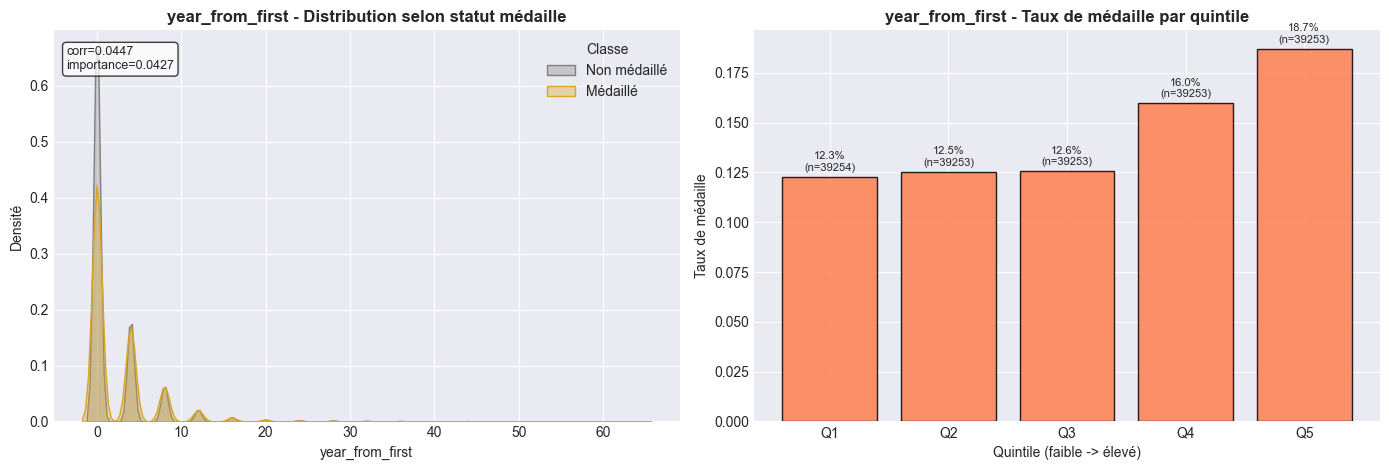

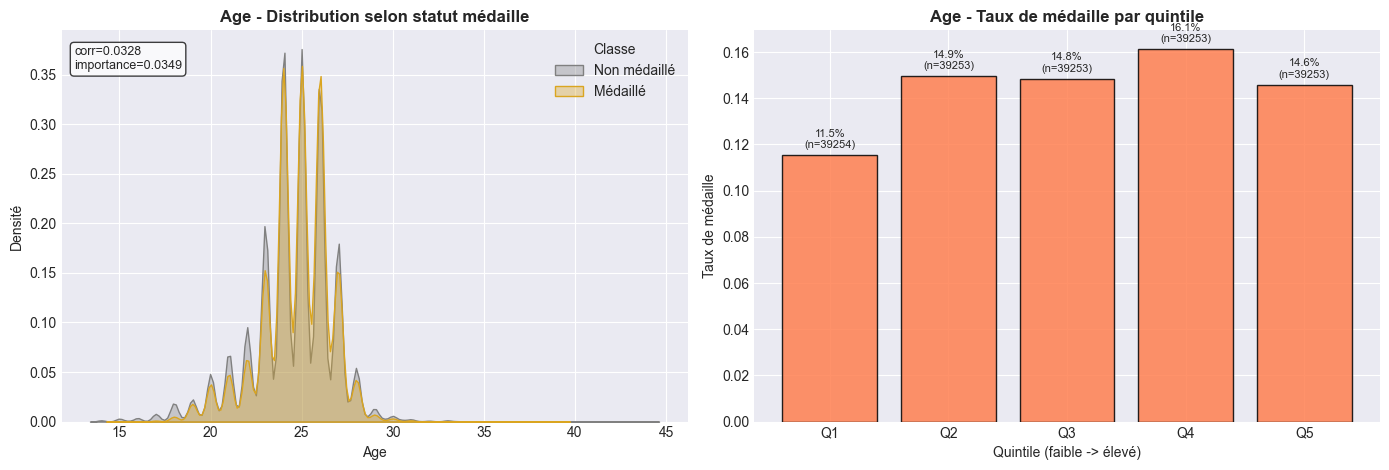

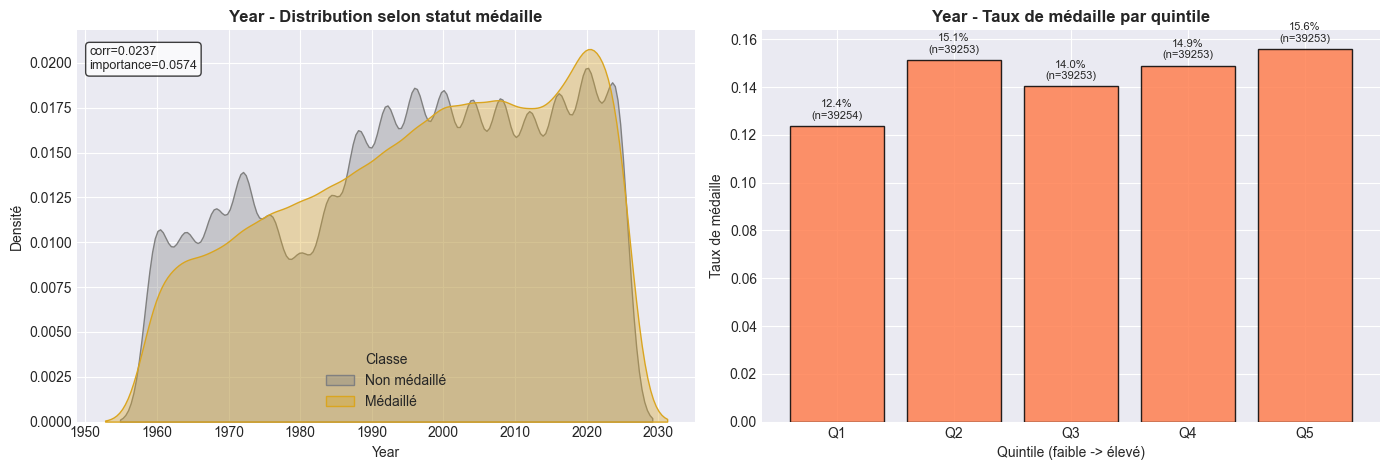


✅ Investigation complète générée pour toutes les features.
➡️ Le notebook peut être exécuté indépendamment du notebook principal.


In [4]:
# Cell 3 - Investigation systématique de CHAQUE feature
print('\n' + '=' * 90)
print('INVESTIGATION MULTI-FEATURES - VERSION AUTONOME')
print('=' * 90)

# Helper: bins robustes même avec beaucoup d'egalites

def build_quantile_bins(series, q=5):
    ranked = series.rank(method='first')
    return pd.qcut(ranked, q=q, labels=[f'Q{i+1}' for i in range(q)])


# 1) Tableau de synthèse chiffrée
summary_rows = []
for feat in feature_cols:
    feat_series = X[feat]
    corr = feat_series.corr(y)
    mean_medal = feat_series[y == 1].mean()
    mean_no_medal = feat_series[y == 0].mean()

    # Separation robuste (effect size approx)
    std_pool = np.sqrt((feat_series[y == 1].var() + feat_series[y == 0].var()) / 2)
    effect_size = (mean_medal - mean_no_medal) / std_pool if std_pool and not np.isnan(std_pool) else np.nan

    # Taux medal par quintile (effet monotone / non-lineaire)
    q_df = pd.DataFrame({'x': feat_series, 'y': y}).dropna().copy()
    q_df['bin'] = build_quantile_bins(q_df['x'], q=5)
    by_bin = q_df.groupby('bin', observed=True)['y'].mean()
    slope_q = by_bin.iloc[-1] - by_bin.iloc[0] if len(by_bin) >= 2 else np.nan

    # Importance modele
    imp_val = float(importance_df.loc[importance_df['feature'] == feat, 'importance'].iloc[0])

    summary_rows.append({
        'feature': feat,
        'corr_with_target': corr,
        'model_importance': imp_val,
        'mean_medal': mean_medal,
        'mean_non_medal': mean_no_medal,
        'delta_mean': mean_medal - mean_no_medal,
        'effect_size_std': effect_size,
        'q5_minus_q1_medal_rate': slope_q
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('model_importance', ascending=False).reset_index(drop=True)

print('\nTableau synthétique (trié par importance modèle):')
print(summary_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# 2) Visualisation globale: importance vs corrélation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_imp = summary_df.sort_values('model_importance', ascending=True)
axes[0].barh(plot_imp['feature'], plot_imp['model_importance'], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Importance modèle par feature (XGBoost)', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

plot_corr = summary_df.sort_values('corr_with_target', ascending=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_corr['corr_with_target']]
axes[1].barh(plot_corr['feature'], plot_corr['corr_with_target'], color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Corrélation linéaire avec has_medal par feature', fontweight='bold')
axes[1].set_xlabel('Pearson correlation')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

# 3) Investigation détaillée par feature (comme pour Age)
for feat in feature_cols:
    feat_series = X[feat]
    corr = feat_series.corr(y)
    imp_val = float(importance_df.loc[importance_df['feature'] == feat, 'importance'].iloc[0])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    # A. Distribution medal vs non-medal
    sns.kdeplot(feat_series[y == 0], fill=True, alpha=0.35, color='gray', label='Non médaillé', ax=axes[0])
    sns.kdeplot(feat_series[y == 1], fill=True, alpha=0.35, color='goldenrod', label='Médaillé', ax=axes[0])
    axes[0].set_title(f'{feat} - Distribution selon statut médaille', fontweight='bold')
    axes[0].set_xlabel(feat)
    axes[0].set_ylabel('Densité')
    axes[0].legend(title='Classe')
    axes[0].text(
        0.02,
        0.96,
        f'corr={corr:.4f}\nimportance={imp_val:.4f}',
        transform=axes[0].transAxes,
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.75)
    )

    # B. Taux de médaille par quintile de la feature
    bdf = pd.DataFrame({'x': feat_series, 'y': y}).dropna().copy()
    bdf['quintile'] = build_quantile_bins(bdf['x'], q=5)
    binned = bdf.groupby('quintile', observed=True)['y'].agg(['mean', 'size']).reset_index()
    axes[1].bar(range(len(binned)), binned['mean'], color='coral', edgecolor='black', alpha=0.85)
    axes[1].set_xticks(range(len(binned)))
    axes[1].set_xticklabels(binned['quintile'].astype(str))
    axes[1].set_title(f'{feat} - Taux de médaille par quintile', fontweight='bold')
    axes[1].set_xlabel('Quintile (faible -> élevé)')
    axes[1].set_ylabel('Taux de médaille')
    for i, row in binned.iterrows():
        axes[1].text(i, row['mean'] + 0.003, f"{row['mean']:.1%}\n(n={int(row['size'])})", ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

print('\n✅ Investigation complète générée pour toutes les features.')
print('➡️ Le notebook peut être exécuté indépendamment du notebook principal.')